# Lab 1 · Calibration, BERT internals, and selective decisions

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/01_calibration_changes_the_decision.ipynb)

**90-minute graduate lab.** Start with a real decision problem, derive and fit
temperature scaling, quantify its uncertainty, and turn calibrated beliefs
into a selective analyst-review policy. Then open FinBERT and follow one batch
from WordPieces through 13 representation stages, a classification head,
calibration, attention diagnostics, and optional integrated gradients.

| Route | Time | What you build |
|---|---:|---|
| **Core · decision calibration** | 35 min | proper scores, reliability, bootstrap uncertainty, review policy |
| **Deep · BERT laboratory** | 40 min | tensors, layer geometry, frozen probes, attention entropy |
| **Stretch · attribution** | 15 min | token-level integrated gradients and an attention comparison |

The default route is fully offline after you upload the frozen CSV. The deep
route downloads public Hugging Face models; no paid API is required.

> **Estimand.** The label is an instructor-coded *favorable direction for the
> named metric*. FinBERT predicts generic financial sentiment. Their mismatch
> is part of the lesson, not a bug or an investment recommendation.

## 1. Setup and data contract

Temperature is fitted **only** on `calibration`; final metrics are reported on
`test`. The cached scorecard reacts to surface direction and magnitude but can
confuse a cost increase with good news. That failure is useful: calibration
can repair confidence, not semantics.

In [1]:
from pathlib import Path
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'blue': '#22577D', 'blue_light': '#5E92B5', 'gold': '#B5862E',
    'gold_light': '#E4D3A6', 'ink': '#1B1915', 'slate': '#6C6457',
    'grid': '#D9D0C0', 'open': '#FBF8F1',
}
REVIEW_THRESHOLD = 0.85
RUN_HUGGINGFACE = False   #@param {type:"boolean"}
RUN_ATTRIBUTION = False   #@param {type:"boolean"}
RUN_BERTVIZ = False       #@param {type:"boolean"}
HF_BATCH_SIZE = 8         #@param {type:"integer"}

if RUN_ATTRIBUTION and not RUN_HUGGINGFACE:
    raise ValueError('RUN_ATTRIBUTION requires RUN_HUGGINGFACE=True.')
if RUN_BERTVIZ and not RUN_HUGGINGFACE:
    raise ValueError('RUN_BERTVIZ requires RUN_HUGGINGFACE=True.')

def load_teaching_csv(filename, **read_csv_kwargs):
    # Use a checkout when present; otherwise prompt for a Colab upload.
    candidates = [
        Path('../teaching-data') / filename,
        Path('teaching-data') / filename,
        Path('/content') / filename,
        Path(filename),
    ]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print('Loading', local)
        return pd.read_csv(local, **read_csv_kwargs)
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f'{filename} not found. Place it in teaching-data/ or the current directory.'
        ) from exc
    print(f'Upload {filename} from the PR teaching-data folder.')
    uploaded = files.upload()
    if filename not in uploaded:
        raise FileNotFoundError(f'Expected {filename}; received {list(uploaded)}')
    return pd.read_csv(BytesIO(uploaded[filename]), **read_csv_kwargs)

df = load_teaching_csv('financial_calibration_sample.csv')
assert {'train', 'calibration', 'test'} == set(df['split'])
print(f'{len(df)} statements from {df.filing_year.nunique()} Microsoft 10-Ks')
display(pd.crosstab(df['split'], df['label_favorable'], margins=True))

Loading ../teaching-data/financial_calibration_sample.csv
37 statements from 2 Microsoft 10-Ks
label_favorable   0   1  All
split                       
calibration       5   7   12
test              6   6   12
train             4   9   13
All              15  22   37


### System map: where calibration sits

Calibration does not retrain BERT and does not change the ranking of examples.
It changes the numerical belief passed from the model to the decision rule.

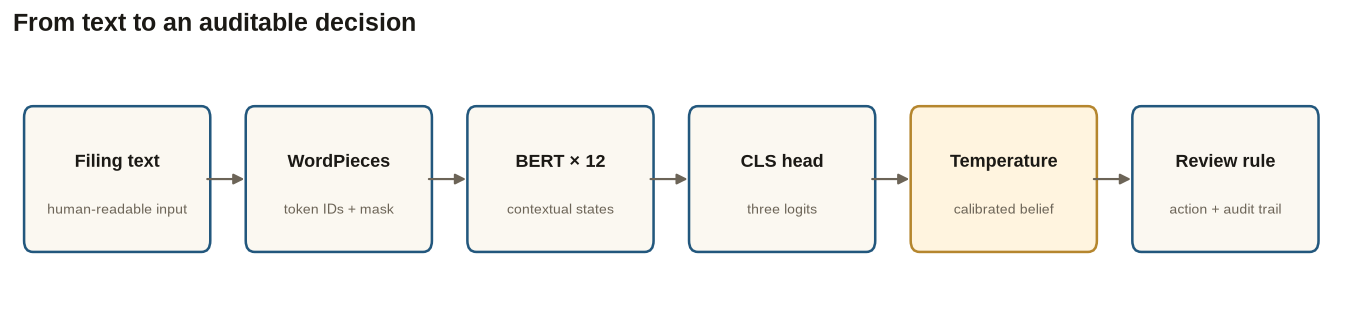

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [
    ('Filing text', 'human-readable input'),
    ('WordPieces', 'token IDs + mask'),
    ('BERT × 12', 'contextual states'),
    ('CLS head', 'three logits'),
    ('Temperature', 'calibrated belief'),
    ('Review rule', 'action + audit trail'),
]
fig, ax = plt.subplots(figsize=(13.2, 2.8))
ax.set_xlim(0, len(stages)); ax.set_ylim(0, 1); ax.axis('off')
for i, (title, subtitle) in enumerate(stages):
    face = COLORS['open'] if i != 4 else '#fff4df'
    edge = COLORS['blue'] if i != 4 else COLORS['gold']
    ax.add_patch(FancyBboxPatch((i+.08, .28), .78, .46,
                 boxstyle='round,pad=.03,rounding_size=.04',
                 facecolor=face, edgecolor=edge, linewidth=1.4))
    ax.text(i+.47, .57, title, ha='center', va='center', fontsize=10,
            color=COLORS['ink'], weight='bold')
    ax.text(i+.47, .40, subtitle, ha='center', va='center', fontsize=8,
            color=COLORS['slate'])
    if i < len(stages)-1:
        ax.add_patch(FancyArrowPatch((i+.86,.51), (i+1.06,.51),
                     arrowstyle='-|>', mutation_scale=12,
                     color=COLORS['slate'], linewidth=1.2))
ax.set_title('From text to an auditable decision', loc='left', fontsize=14,
             color=COLORS['ink'], weight='bold')
plt.show()

### Predict before running

One positive temperature divides every logit by the same number. Write down
whether you expect it to change (a) ranking, (b) 50% accuracy, (c) NLL, and
(d) the set of cases crossing an 85% review threshold.

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))

def log_loss(y, p):
    p = np.clip(np.asarray(p), 1e-12, 1 - 1e-12)
    y = np.asarray(y)
    return float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

def brier(y, p):
    return float(np.mean((np.asarray(p) - np.asarray(y))**2))

def ece(y, p, edges=np.linspace(0, 1, 6)):
    y, p = np.asarray(y), np.asarray(p)
    total = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        take = (p >= lo) & (p <= hi if hi == 1 else p < hi)
        if take.any():
            total += take.mean() * abs(p[take].mean() - y[take].mean())
    return float(total)

cal = df.query("split == 'calibration'").copy()
test = df.query("split == 'test'").copy()

grid = np.geomspace(0.25, 8.0, 3000)
losses = [log_loss(cal.label_favorable, sigmoid(cal.raw_logit / t)) for t in grid]
T_hat = float(grid[np.argmin(losses)])
print(f'Fitted temperature on calibration only: T = {T_hat:.3f}')

Fitted temperature on calibration only: T = 1.804


### 1.1 Inspect the objective and its sampling uncertainty

Temperature scaling minimizes calibration-set negative log-likelihood,

$$\widehat T=\arg\min_{T>0}-\frac1n\sum_i\left[y_i\log\sigma(z_i/T)
+(1-y_i)\log(1-\sigma(z_i/T))\right].$$

With only 12 calibration rows, reporting a single optimum without uncertainty
would look more precise than the experiment is. The bootstrap below resamples
calibration rows and refits the *entire* temperature.

Bootstrap median=1.79; 95% interval=(0.25, 8.00)


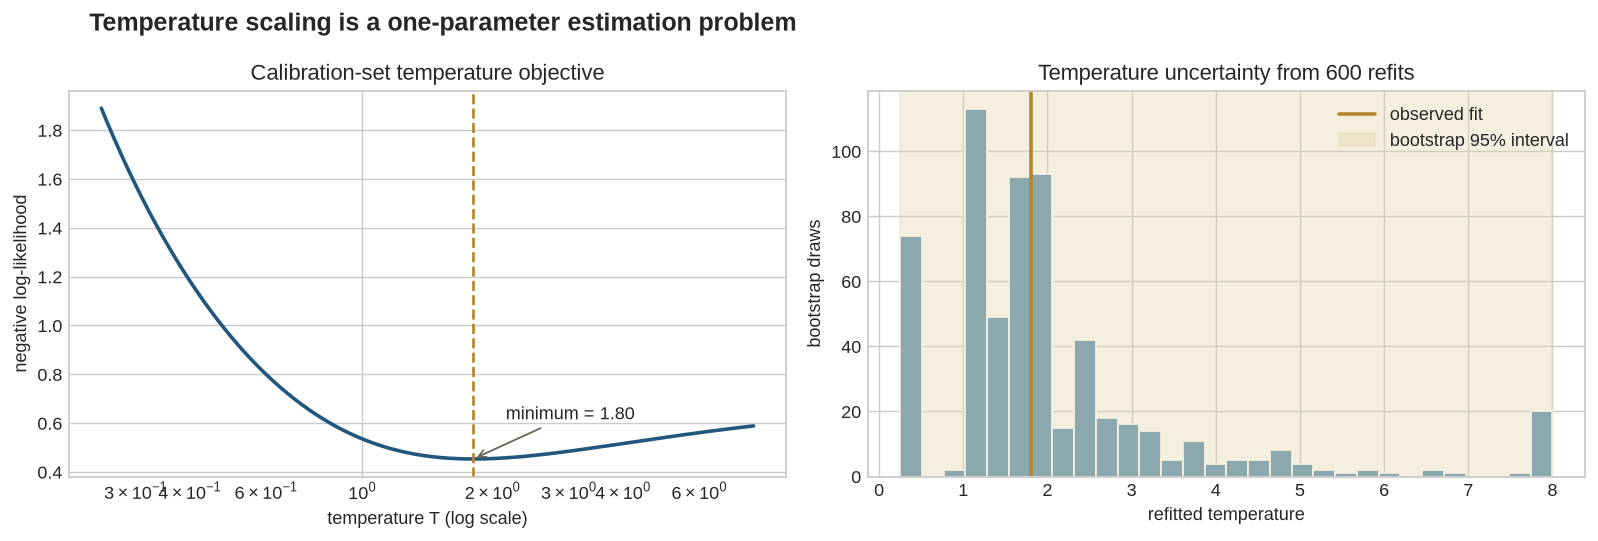

In [4]:
calibration_rng = np.random.default_rng(2026)
bootstrap_temperatures = []
for _ in range(600):
    draw = cal.sample(len(cal), replace=True,
                      random_state=int(calibration_rng.integers(1_000_000_000)))
    draw_losses = [log_loss(draw.label_favorable,
                            sigmoid(draw.raw_logit / temperature))
                   for temperature in grid]
    bootstrap_temperatures.append(float(grid[np.argmin(draw_losses)]))

t_lo, t_median, t_hi = np.quantile(bootstrap_temperatures, [.025, .5, .975])
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
axes[0].plot(grid, losses, color=COLORS['blue'], linewidth=2)
axes[0].axvline(T_hat, color=COLORS['gold'], linestyle='--', linewidth=1.5)
axes[0].set_xscale('log')
axes[0].set(title='Calibration-set temperature objective',
            xlabel='temperature T (log scale)', ylabel='negative log-likelihood')
axes[0].annotate(f'minimum = {T_hat:.2f}', (T_hat, min(losses)),
                 xytext=(18, 22), textcoords='offset points',
                 arrowprops={'arrowstyle':'->', 'color':COLORS['slate']})

axes[1].hist(bootstrap_temperatures, bins=30, color=COLORS['blue_light'],
             edgecolor='white')
axes[1].axvline(T_hat, color=COLORS['gold'], linewidth=2, label='observed fit')
axes[1].axvspan(t_lo, t_hi, color=COLORS['gold_light'], alpha=.35,
                label='bootstrap 95% interval')
axes[1].set(title='Temperature uncertainty from 600 refits',
            xlabel='refitted temperature', ylabel='bootstrap draws')
axes[1].legend(frameon=False)
fig.suptitle('Temperature scaling is a one-parameter estimation problem',
             x=.06, ha='left', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()
print(f'Bootstrap median={t_median:.2f}; 95% interval=({t_lo:.2f}, {t_hi:.2f})')

## 2. Untouched test evaluation

Accuracy at 50% is an invariant here. Proper scoring rules should improve if
the calibration split diagnosed the same confidence error present in test.

In [5]:
def evaluate(frame, temperature, threshold=0.85):
    y = frame.label_favorable.to_numpy()
    p = sigmoid(frame.raw_logit.to_numpy() / temperature)
    return {
        'NLL': log_loss(y, p), 'Brier': brier(y, p), 'ECE (5 bins)': ece(y, p),
        'Accuracy @ 0.50': np.mean((p >= .5) == y),
        f'Review rate @ {threshold:.2f}': np.mean(p >= threshold),
    }

comparison = pd.DataFrame({
    'raw (T=1)': evaluate(test, 1.0),
    f'calibrated (T={T_hat:.2f})': evaluate(test, T_hat),
})
display(comparison.round(3))
assert comparison.loc['Accuracy @ 0.50'].nunique() == 1
assert comparison.loc['NLL'].iloc[1] < comparison.loc['NLL'].iloc[0]

                    raw (T=1)  calibrated (T=1.80)
NLL                     0.705                0.553
Brier                   0.219                0.186
ECE (5 bins)            0.230                0.175
Accuracy @ 0.50         0.750                0.750
Review rate @ 0.85      0.750                0.250


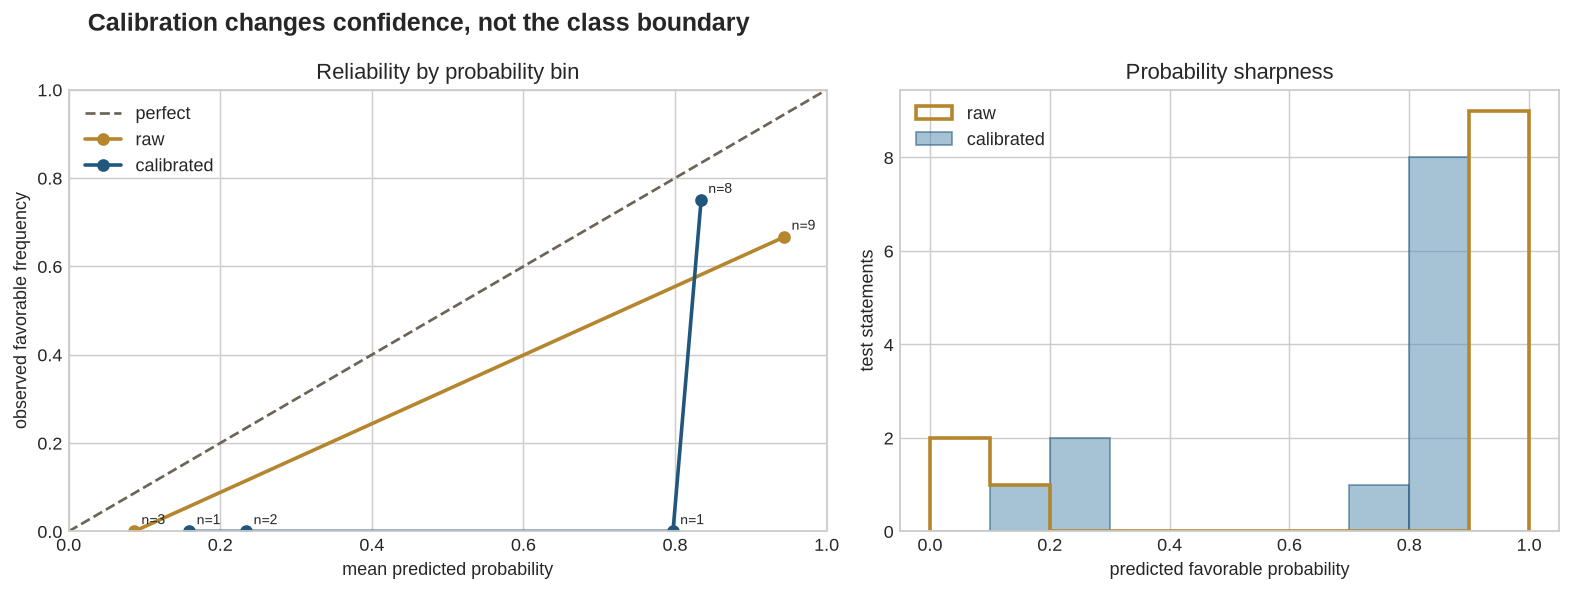

In [6]:
def reliability_points(y, p, edges=np.linspace(0, 1, 6)):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        take = (p >= lo) & (p <= hi if hi == 1 else p < hi)
        if take.any(): out.append((p[take].mean(), y[take].mean(), take.sum()))
    return np.array(out)

y = test.label_favorable.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), gridspec_kw={'width_ratios':[1.15,1]})
ax = axes[0]
ax.plot([0, 1], [0, 1], '--', color=COLORS['slate'], label='perfect')
for name, temp, color in [('raw', 1.0, COLORS['gold']), ('calibrated', T_hat, COLORS['blue'])]:
    pts = reliability_points(y, sigmoid(test.raw_logit / temp))
    ax.plot(pts[:,0], pts[:,1], 'o-', lw=2, color=color, label=name)
    for x, yy, n in pts: ax.annotate(f'n={int(n)}', (x, yy), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.set(xlim=(0,1), ylim=(0,1), xlabel='mean predicted probability',
       ylabel='observed favorable frequency', title='Reliability by probability bin')
ax.legend(frameon=False)

raw_probability = sigmoid(test.raw_logit)
calibrated_probability = sigmoid(test.raw_logit / T_hat)
bins = np.linspace(0, 1, 11)
axes[1].hist(raw_probability, bins=bins, histtype='step', linewidth=2,
             color=COLORS['gold'], label='raw')
axes[1].hist(calibrated_probability, bins=bins, alpha=.55,
             color=COLORS['blue_light'], edgecolor=COLORS['blue'],
             label='calibrated')
axes[1].set(title='Probability sharpness', xlabel='predicted favorable probability',
            ylabel='test statements')
axes[1].legend(frameon=False)
fig.suptitle('Calibration changes confidence, not the class boundary',
             x=.06, ha='left', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

## 3. Convert probabilities into a workflow decision

At 50%, temperature scaling cannot change the class. At a higher confidence
threshold it can change who consumes scarce analyst time.

In [7]:
THRESHOLD = REVIEW_THRESHOLD
review = test[['id','group','text','label_favorable','raw_logit']].copy()
review['p_raw'] = sigmoid(review.raw_logit)
review['p_calibrated'] = sigmoid(review.raw_logit / T_hat)
review['review_raw'] = review.p_raw >= THRESHOLD
review['review_calibrated'] = review.p_calibrated >= THRESHOLD
display(review[['group','text','label_favorable','p_raw','p_calibrated','review_raw','review_calibrated']].round(3))
print('Changed workflow decisions:', int((review.review_raw != review.review_calibrated).sum()))

       group  ... review_calibrated
2    product  ...              True
5    product  ...             False
8    product  ...             False
11      cost  ...             False
17  headline  ...              True
20   product  ...             False
23      cost  ...             False
26   product  ...             False
29      cost  ...             False
32   segment  ...              True
35  headline  ...             False
36    margin  ...             False

[12 rows x 7 columns]
Changed workflow decisions: 6


In [8]:
rows = []
for group, g in test.groupby('group'):
    raw = evaluate(g, 1.0)
    calibrated = evaluate(g, T_hat)
    rows.append({'group': group, 'n': len(g), 'NLL raw': raw['NLL'], 'NLL calibrated': calibrated['NLL'],
                 'accuracy': calibrated['Accuracy @ 0.50']})
subgroup = pd.DataFrame(rows).sort_values('NLL calibrated')
display(subgroup.round(3))
print('Small subgroups are diagnostic prompts, not precise population estimates.')

      group  n  NLL raw  NLL calibrated  accuracy
4   segment  1    0.033           0.141       1.0
1  headline  2    0.044           0.165       1.0
3   product  5    0.065           0.198       1.0
2    margin  1    0.119           0.276       1.0
0      cost  3    2.632           1.635       0.0
Small subgroups are diagnostic prompts, not precise population estimates.


### 3.1 Selective prediction: coverage, risk, and cost

A model need not automate every statement. Sort cases by distance from 50%,
answer only the most confident fraction, and send the rest to a human. Because
positive temperature scaling preserves ranking, raw and calibrated models have
the same risk–coverage curve—even though a fixed 85% threshold selects a
different number of cases.

The second panel asks a different question: which probability threshold
minimizes empirical loss when a missed unfavorable statement is more costly
than an unnecessary review?

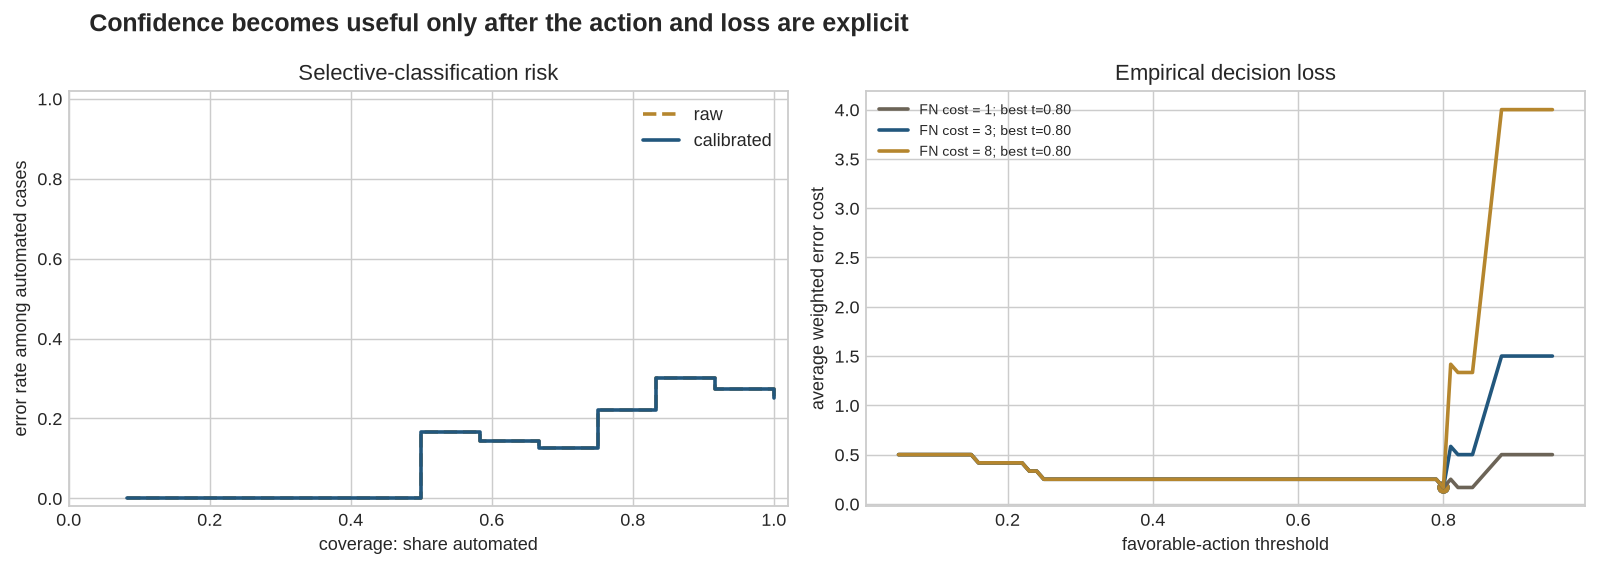

In [9]:
def risk_coverage(y_true, probability):
    confidence = np.abs(np.asarray(probability) - .5)
    order = np.argsort(-confidence)
    selected_error = ((np.asarray(probability)[order] >= .5) != np.asarray(y_true)[order])
    coverage = np.arange(1, len(order)+1) / len(order)
    risk = np.cumsum(selected_error) / np.arange(1, len(order)+1)
    return coverage, risk

thresholds = np.linspace(.05, .95, 91)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
for name, probability, color, style in [
    ('raw', review.p_raw, COLORS['gold'], '--'),
    ('calibrated', review.p_calibrated, COLORS['blue'], '-'),
]:
    coverage, risk = risk_coverage(y, probability)
    axes[0].step(coverage, risk, where='post', color=color, linestyle=style,
                 linewidth=2, label=name)
axes[0].set(title='Selective-classification risk',
            xlabel='coverage: share automated', ylabel='error rate among automated cases',
            xlim=(0,1.02), ylim=(-.02,1.02))
axes[0].legend(frameon=False)

p = review.p_calibrated.to_numpy()
for false_negative_cost, color in [(1, COLORS['slate']), (3, COLORS['blue']),
                                    (8, COLORS['gold'])]:
    losses_by_threshold = []
    for threshold in thresholds:
        decision = p >= threshold
        false_positive = (decision & (y == 0)).mean()
        false_negative = ((~decision) & (y == 1)).mean()
        losses_by_threshold.append(false_positive + false_negative_cost*false_negative)
    losses_by_threshold = np.asarray(losses_by_threshold)
    best = int(np.argmin(losses_by_threshold))
    axes[1].plot(thresholds, losses_by_threshold, color=color, linewidth=2,
                 label=f'FN cost = {false_negative_cost}; best t={thresholds[best]:.2f}')
    axes[1].scatter(thresholds[best], losses_by_threshold[best], color=color, s=35)
axes[1].set(title='Empirical decision loss', xlabel='favorable-action threshold',
            ylabel='average weighted error cost')
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle('Confidence becomes useful only after the action and loss are explicit',
             x=.06, ha='left', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

## 4. Reproduction path: train a local baseline

This optional cell replaces the cached scorecard with a fully local TF-IDF
logistic regression. The tiny split is intentionally not a benchmark; the
purpose is to make the score-generation path inspectable.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train = df.query("split == 'train'")
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_train = vectorizer.fit_transform(train.text)
baseline = LogisticRegression(C=1.0, random_state=2026).fit(X_train, train.label_favorable)
local_test_logit = baseline.decision_function(vectorizer.transform(test.text))
print('Local baseline test NLL:', round(log_loss(test.label_favorable, sigmoid(local_test_logit)), 3))

Local baseline test NLL: 0.706


## 5. Deep path: open the BERT black box

This section is optional and deliberately more computational. It uses
[`ProsusAI/finbert`](https://huggingface.co/ProsusAI/finbert), a BERT model
adapted to financial sentiment. Our label is *favorable direction for the named
metric*, not generic sentiment, so this is a transfer experiment rather than a
benchmark. Set the switch below to `True`; a public model does not require a
token, although a private `HF_TOKEN` Colab secret is used when available.

In [11]:
FINBERT_MODEL = 'ProsusAI/finbert'

if RUN_HUGGINGFACE:
    import subprocess, sys
    packages = ['transformers>=4.45,<6', 'accelerate>=1,<3']
    if RUN_ATTRIBUTION:
        packages.append('captum>=0.8,<1')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
    print('Hugging Face path enabled.')
else:
    print('Fast path active. Set RUN_HUGGINGFACE=True to run the BERT laboratory.')

Fast path active. Set RUN_HUGGINGFACE=True to run the BERT laboratory.


### 5.1 WordPiece tokenization: what BERT actually receives

Predict where the filing sentence will split into subwords. `##` means that a
piece continues the preceding word; `[CLS]` is the pooled classification token.

In [12]:
if RUN_HUGGINGFACE:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from matplotlib.patches import FancyBboxPatch

    def colab_secret(name):
        try:
            from google.colab import userdata
            return userdata.get(name)
        except Exception:
            return None

    hf_token = colab_secret('HF_TOKEN')
    load_kwargs = {'token': hf_token} if hf_token else {}
    tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL, **load_kwargs)

    example_index = int(test.index[0])
    example_text = df.loc[example_index, 'text']
    token_ids = tokenizer(example_text, truncation=True, max_length=64)['input_ids']
    pieces = tokenizer.convert_ids_to_tokens(token_ids)

    def plot_wordpieces(tokens, columns=9):
        rows = int(np.ceil(len(tokens) / columns))
        fig, ax = plt.subplots(figsize=(12, max(2.2, 0.72*rows)))
        ax.set_xlim(0, columns); ax.set_ylim(0, rows); ax.axis('off')
        for i, token in enumerate(tokens):
            row, col = divmod(i, columns); y = rows-row-1
            continuation = token.startswith('##')
            special = token.startswith('[')
            face = COLORS['open'] if special else (COLORS['gold_light'] if continuation else '#DCE7EF')
            edge = COLORS['slate'] if special else (COLORS['gold'] if continuation else COLORS['blue'])
            ax.add_patch(FancyBboxPatch((col+.06, y+.16), .88, .62,
                boxstyle='round,pad=0.03,rounding_size=0.06', facecolor=face,
                edgecolor=edge, linewidth=1.1))
            ax.text(col+.5, y+.47, token, ha='center', va='center', fontsize=9)
        ax.set_title('FinBERT WordPiece sequence\nblue = new word, gold = continuation, grey = special token', loc='left')
        plt.show()

    print(example_text)
    plot_wordpieces(pieces)

### 5.2 Batched inference: logits, hidden states, and attention

We request all three objects explicitly. Logits drive the classifier; the
final `[CLS]` vector is a 768-dimensional representation; attention has shape
`layer × head × query-token × key-token`.

In [13]:
if RUN_HUGGINGFACE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = AutoModelForSequenceClassification.from_pretrained(
        FINBERT_MODEL, output_hidden_states=True, output_attentions=False,
        attn_implementation='eager', **load_kwargs
    ).to(device).eval()

    # Hidden states are collected in small batches. Attention is intentionally
    # excluded here: all-layer O(n_tokens^2) tensors for the whole corpus can
    # consume gigabytes. We request attention later for one example only.
    logits_batches = []
    layer_cls_batches = None
    for start in range(0, len(df), HF_BATCH_SIZE):
        batch_text = df.text.iloc[start:start+HF_BATCH_SIZE].tolist()
        batch = tokenizer(batch_text, padding=True, truncation=True,
                          max_length=128, return_tensors='pt')
        batch_device = {key: value.to(device) for key, value in batch.items()}
        with torch.no_grad():
            batch_output = model(**batch_device, output_hidden_states=True,
                                 output_attentions=False)
        logits_batches.append(batch_output.logits.detach().cpu())
        if layer_cls_batches is None:
            layer_cls_batches = [[] for _ in batch_output.hidden_states]
        for layer, hidden_state in enumerate(batch_output.hidden_states):
            layer_cls_batches[layer].append(hidden_state[:, 0, :].detach().cpu())

    logits_tensor = torch.cat(logits_batches, dim=0)
    logits = logits_tensor.numpy()
    probabilities = torch.softmax(logits_tensor, dim=-1).numpy()
    layer_cls_embeddings = np.stack([
        torch.cat(parts, dim=0).numpy() for parts in layer_cls_batches
    ])  # layer × statement × hidden dimension
    cls_embeddings = layer_cls_embeddings[-1]
    labels = [model.config.id2label[i].lower() for i in range(model.config.num_labels)]
    positive_index = next(i for i, label in enumerate(labels) if 'positive' in label)
    negative_index = next(i for i, label in enumerate(labels) if 'negative' in label)
    finbert_logit = logits[:, positive_index] - logits[:, negative_index]
    finbert = df[['id','split','group','label_favorable','text']].copy()
    finbert['p_positive'] = probabilities[:, positive_index]
    finbert['p_negative'] = probabilities[:, negative_index]
    finbert['p_neutral'] = probabilities[:, next(i for i in range(len(labels)) if i not in {positive_index, negative_index})]
    finbert['direction_logit'] = finbert_logit
    print('device:', device, '| logits:', logits.shape,
          '| layer CLS tensor:', layer_cls_embeddings.shape)
    display(finbert[['group','text','p_positive','p_negative','p_neutral']].head().round(3))

### 5.3 Watch representations change across the network

BERT returns the embedding output plus one hidden state per Transformer block:
13 stages for BERT-base. We project layers 0, 4, 8, and 12 separately and then
compute a descriptive cosine-silhouette statistic for every layer. This is a
representation diagnostic on all 37 statements—not an out-of-sample score.

In [14]:
if RUN_HUGGINGFACE:
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score

    selected_layers = [0, 4, 8, 12]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))
    label_colors = np.where(df.label_favorable.to_numpy() == 1,
                            COLORS['blue'], COLORS['gold'])
    split_markers = {'train':'o', 'calibration':'s', 'test':'^'}
    for ax, layer in zip(axes.flat, selected_layers):
        coordinates = PCA(n_components=2, random_state=2026).fit_transform(
            layer_cls_embeddings[layer])
        for split_name, marker in split_markers.items():
            take = df.split.eq(split_name).to_numpy()
            ax.scatter(coordinates[take,0], coordinates[take,1], s=58,
                       marker=marker, c=label_colors[take], edgecolor='white',
                       linewidth=.7, label=split_name)
        ax.axhline(0, color=COLORS['grid'], lw=.7)
        ax.axvline(0, color=COLORS['grid'], lw=.7)
        ax.set(title=f'layer {layer}', xlabel='PC1', ylabel='PC2')
    handles, labels_legend = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels_legend, loc='upper center', ncol=3, frameon=False)
    fig.suptitle('Evolution of FinBERT [CLS] representations\ncolor = teaching label; shape = split; each panel has its own PCA',
                 y=1.02, fontsize=14, weight='bold')
    plt.tight_layout(); plt.show()

    layer_silhouette = []
    for hidden in layer_cls_embeddings:
        normalized = hidden / np.clip(np.linalg.norm(hidden, axis=1, keepdims=True), 1e-12, None)
        layer_silhouette.append(silhouette_score(
            normalized, df.label_favorable.to_numpy(), metric='cosine'))
    fig, ax = plt.subplots(figsize=(8.4, 3.8))
    ax.plot(range(len(layer_silhouette)), layer_silhouette, marker='o',
            color=COLORS['blue'], linewidth=2)
    ax.axhline(0, color=COLORS['slate'], linewidth=1)
    ax.set(title='Descriptive label separation across FinBERT layers',
           xlabel='representation stage (0 = embeddings)',
           ylabel='cosine silhouette')
    plt.show()

### 5.4 Frozen probe and calibrated zero-shot scores

With only 13 training rows, full BERT fine-tuning would be an overfitting demo.
Instead we freeze BERT and estimate only a linear boundary. Separately, we fit
one temperature to FinBERT's positive-minus-negative logit on calibration rows.

In [15]:
if RUN_HUGGINGFACE:
    from sklearn.linear_model import LogisticRegression
    train_mask = df.split.eq('train').to_numpy()
    calibration_mask = df.split.eq('calibration').to_numpy()
    test_mask = df.split.eq('test').to_numpy()
    probe = LogisticRegression(C=.2, random_state=2026).fit(
        cls_embeddings[train_mask], df.loc[train_mask, 'label_favorable'])
    probe_test_probability = probe.predict_proba(cls_embeddings[test_mask])[:,1]

    hf_grid = np.geomspace(.1, 20, 3000)
    hf_losses = [log_loss(df.loc[calibration_mask,'label_favorable'],
                          sigmoid(finbert_logit[calibration_mask]/temperature))
                 for temperature in hf_grid]
    hf_temperature = float(hf_grid[np.argmin(hf_losses)])
    hf_raw = sigmoid(finbert_logit[test_mask])
    hf_calibrated = sigmoid(finbert_logit[test_mask]/hf_temperature)
    y_test = df.loc[test_mask,'label_favorable'].to_numpy()
    model_comparison = pd.DataFrame({
        'NLL': [log_loss(y_test, hf_raw), log_loss(y_test, hf_calibrated), log_loss(y_test, probe_test_probability)],
        'Brier': [brier(y_test, hf_raw), brier(y_test, hf_calibrated), brier(y_test, probe_test_probability)],
        'Accuracy @ 0.50': [np.mean((hf_raw>=.5)==y_test), np.mean((hf_calibrated>=.5)==y_test), np.mean((probe_test_probability>=.5)==y_test)]
    }, index=['FinBERT zero-shot','FinBERT + temperature','Frozen CLS probe'])
    print(f'FinBERT calibration-only temperature: {hf_temperature:.3f}')
    display(model_comparison.round(3))

    # Probe every second layer using the same frozen train/test contract.
    probe_path = []
    for layer in range(0, layer_cls_embeddings.shape[0], 2):
        layer_probe = LogisticRegression(C=.2, random_state=2026).fit(
            layer_cls_embeddings[layer, train_mask],
            df.loc[train_mask, 'label_favorable'])
        layer_probability = layer_probe.predict_proba(
            layer_cls_embeddings[layer, test_mask])[:,1]
        probe_path.append({
            'layer': layer,
            'NLL': log_loss(y_test, layer_probability),
            'accuracy': np.mean((layer_probability >= .5) == y_test),
        })
    probe_path = pd.DataFrame(probe_path)
    fig, ax_left = plt.subplots(figsize=(8.5, 4.1))
    ax_left.plot(probe_path.layer, probe_path.NLL, marker='o',
                 color=COLORS['blue'], linewidth=2, label='test NLL')
    ax_left.set(xlabel='frozen representation layer', ylabel='test NLL')
    ax_right = ax_left.twinx()
    ax_right.plot(probe_path.layer, probe_path.accuracy, marker='s',
                  color=COLORS['gold'], linestyle='--', linewidth=1.8,
                  label='test accuracy')
    ax_right.set(ylabel='test accuracy', ylim=(0,1.02))
    lines = ax_left.get_lines() + ax_right.get_lines()
    ax_left.legend(lines, [line.get_label() for line in lines], frameon=False)
    ax_left.set_title('Frozen probes across layers\n13 train and 12 test rows: exploratory, not a benchmark')
    plt.show()

### 5.5 Attention by head: a diagnostic, not an explanation

The heatmap shows where each final-layer head sends attention from `[CLS]` for
one statement. Attention is part of the computation, but it is not a causal
feature attribution and should not be sold as one.

In [16]:
if RUN_HUGGINGFACE:
    single_encoded = tokenizer(example_text, truncation=True, max_length=64,
                               return_tensors='pt')
    single_device = {key: value.to(device) for key, value in single_encoded.items()}
    with torch.no_grad():
        example_output = model(**single_device, output_hidden_states=False,
                               output_attentions=True)
    attention_stack = np.stack([
        layer[0].detach().cpu().numpy() for layer in example_output.attentions
    ])  # layer × head × query token × key token
    sequence_length = int(single_encoded['attention_mask'][0].sum())
    token_labels = tokenizer.convert_ids_to_tokens(
        single_encoded['input_ids'][0, :sequence_length])
    cls_attention = attention_stack[:, :, 0, :sequence_length]
    entropy = -(cls_attention * np.log(np.clip(cls_attention, 1e-12, None))).sum(axis=-1)
    entropy = entropy / np.log(sequence_length)

    shown = min(sequence_length, 36)
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1),
                             gridspec_kw={'width_ratios':[1,1.5]})
    entropy_image = axes[0].imshow(entropy, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[0].set(title='[CLS] attention entropy', xlabel='head', ylabel='layer')
    axes[0].set_xticks(range(entropy.shape[1]), [f'H{i+1}' for i in range(entropy.shape[1])],
                       rotation=45, ha='right', fontsize=7)
    axes[0].set_yticks(range(entropy.shape[0]), [f'L{i+1}' for i in range(entropy.shape[0])])
    fig.colorbar(entropy_image, ax=axes[0], label='normalized entropy', shrink=.8)

    final_attention = cls_attention[-1, :, :shown]
    attention_image = axes[1].imshow(final_attention, aspect='auto', cmap='Blues')
    axes[1].set(title='Final-layer attention from [CLS]', xlabel='key token',
                ylabel='attention head')
    axes[1].set_xticks(range(shown), token_labels[:shown], rotation=70,
                       ha='right', fontsize=8)
    axes[1].set_yticks(range(final_attention.shape[0]),
                       [f'H{head+1}' for head in range(final_attention.shape[0])])
    fig.colorbar(attention_image, ax=axes[1], label='attention weight', shrink=.8)
    fig.suptitle('Attention heads differ in focus and token allocation\ncomputation diagnostic—not causal feature importance',
                 x=.06, ha='left', fontsize=14, weight='bold')
    plt.tight_layout(); plt.show()

### 5.5b Interactive attention with BertViz — a minimal pair

[BertViz](https://github.com/jessevig/bertviz) renders every head in every
layer as an interactive diagram. Static heatmaps compress; this lets you
*browse*. To make browsing purposeful, the cell runs FinBERT on the example
statement **and on a minimal pair** with the direction word flipped
(`increased` ↔ `decreased`) — the one-token change that moves the label.

**What to look for, in order:**
1. the `[SEP]`/`[CLS]` *sink* heads — most attention mass parked on
   delimiters, a well-documented default;
2. *positional* heads attending one token back — the same previous-token
   pattern that Session 1's induction circuit builds on;
3. heads whose pattern **moves** when the direction word flips — candidates
   for where the sentiment decision is mixed.

The same caveat as above, now interactive: attention is the model's mixing
diagram, not a causal explanation — the integrated-gradients section below
asks the attribution question properly.

In [17]:
if RUN_BERTVIZ:
    import importlib.util, subprocess, sys
    if importlib.util.find_spec('bertviz') is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'bertviz'])
    from bertviz import head_view, model_view

    if 'increased' in example_text:
        swapped_text = example_text.replace('increased', 'decreased')
    elif 'decreased' in example_text:
        swapped_text = example_text.replace('decreased', 'increased')
    else:
        swapped_text = example_text
    attention_views = {}
    for view_name, sentence in [('original', example_text), ('swapped', swapped_text)]:
        encoded = tokenizer(sentence, truncation=True, max_length=48,
                            return_tensors='pt')
        with torch.no_grad():
            view_output = model(**{key: value.to(device)
                                   for key, value in encoded.items()},
                                output_attentions=True)
        attention_views[view_name] = (
            [layer.cpu() for layer in view_output.attentions],
            tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]),
        )
        print(f'{view_name}: {sentence}')
    attention_layers, view_tokens = attention_views['original']
    head_view(attention_layers, view_tokens)
else:
    print('Set RUN_BERTVIZ=True (with RUN_HUGGINGFACE=True) for the interactive views.')

Set RUN_BERTVIZ=True (with RUN_HUGGINGFACE=True) for the interactive views.


In [18]:
if RUN_BERTVIZ:
    # The model view draws the full 12 x 12 grid -- heavier, but the fastest
    # way to *find* the sink heads and the positional heads named above.
    # Then re-run both views with attention_views['swapped'] and diff by eye.
    model_view(attention_layers, view_tokens)

### 5.6 Stretch: integrated gradients on the embedding layer

Attention describes information mixing inside the model. Integrated gradients
asks a different, local question: along a path from a baseline token sequence
to this sentence, which embedding dimensions contribute to FinBERT's
positive-minus-negative logit? The result still depends on the baseline and is
not a structural or causal explanation.

In [19]:
if RUN_ATTRIBUTION:
    from captum.attr import LayerIntegratedGradients

    input_ids = single_device['input_ids']
    attention_mask = single_device['attention_mask']
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline_ids[:, 0] = tokenizer.cls_token_id
    sep_position = int(attention_mask[0].sum()) - 1
    baseline_ids[:, sep_position] = tokenizer.sep_token_id

    def direction_forward(ids, mask):
        model_logits = model(input_ids=ids, attention_mask=mask,
                             output_attentions=False).logits
        return model_logits[:, positive_index] - model_logits[:, negative_index]

    embedding_layer = model.bert.embeddings
    layer_ig = LayerIntegratedGradients(direction_forward, embedding_layer)
    attribution, convergence_delta = layer_ig.attribute(
        inputs=input_ids, baselines=baseline_ids,
        additional_forward_args=(attention_mask,), n_steps=32,
        internal_batch_size=8, return_convergence_delta=True)
    token_attribution = attribution.sum(dim=-1)[0, :sequence_length].detach().cpu().numpy()
    token_attribution /= np.clip(np.max(np.abs(token_attribution)), 1e-12, None)
    token_colors = [COLORS['blue'] if value >= 0 else COLORS['gold']
                    for value in token_attribution]

    fig, ax = plt.subplots(figsize=(9.5, max(3.6, .30*sequence_length)))
    y_position = np.arange(sequence_length)
    ax.barh(y_position, token_attribution, color=token_colors, edgecolor='white')
    ax.axvline(0, color=COLORS['ink'], linewidth=1)
    ax.set_yticks(y_position, token_labels)
    ax.invert_yaxis()
    ax.set(title='Layer integrated gradients for FinBERT direction logit\nblue pushes positive; gold pushes negative',
           xlabel='normalized attribution', ylabel='token')
    plt.tight_layout(); plt.show()

    mean_final_attention = final_attention.mean(axis=0)[:sequence_length]
    attribution_attention_correlation = np.corrcoef(
        np.abs(token_attribution[:len(mean_final_attention)]), mean_final_attention)[0,1]
    print('Integrated-gradients convergence delta:',
          float(convergence_delta.detach().cpu().reshape(-1)[0]))
    print('Correlation of |IG| with mean final-layer [CLS] attention:',
          round(float(attribution_attention_correlation), 3))
    print('Low agreement is not a contradiction: the two diagnostics answer different questions.')
elif RUN_HUGGINGFACE:
    print('Set RUN_ATTRIBUTION=True and rerun from setup for integrated gradients.')

## 6. Checks and next steps

- `T_hat` used only calibration rows; test metrics were computed afterward.
- Temperature scaling preserved rank and the 50% decision boundary.
- The real intervention is a policy: choose a loss and threshold that reflect
  the cost of unnecessary review versus missed unfavorable statements.

- The Hugging Face path keeps the model frozen; no 13-row fine-tuning claim is made.
- FinBERT sentiment and the teaching estimand are explicitly kept distinct.
- Corpus inference batches hidden states and requests quadratic attention tensors
  only for one example, avoiding a common Colab memory failure.
- Attention and integrated gradients are kept distinct and explicitly non-causal.

**Extension:** enlarge the hand-coded corpus before considering LoRA or full
fine-tuning; then pre-register the split and compare against the frozen probe.